In [1]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import wasserstein_distance
from tqdm import tqdm
import pickle

In [2]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define Transforms (Resize -> CenterCrop -> Normalize)
embed_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Using device: cuda


In [3]:
class HFStreamImageDataset(IterableDataset):
    def __init__(self, hf_name, split="train", image_key="image", shuffle_buffer=10000, seed=42, max_samples=2000, tfms=None):
        self.ds = load_dataset(hf_name, split=split, streaming=True)
        self.ds = self.ds.shuffle(buffer_size=shuffle_buffer, seed=seed)
        self.image_key = image_key
        self.max_samples = max_samples
        self.tfms = tfms

    def __iter__(self):
        n = 0
        for ex in self.ds:
            if n >= self.max_samples: break
            img = ex[self.image_key]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            pil_img = img.convert("RGB")
            x = self.tfms(pil_img) if self.tfms else pil_img
            yield x, pil_img, n
            n += 1

def custom_collate_fn(batch):
    tensors = torch.stack([item[0] for item in batch])
    pil_images = [item[1] for item in batch]
    ids = [item[2] for item in batch]
    return tensors, pil_images, ids

In [4]:
# Load Frozen Backbone (ResNet50)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device)
backbone.eval()

def extract_embeddings(hf_name, split="train", max_samples=2000, batch_size=32):
    print(f"Extracting {max_samples} samples from {hf_name}...")
    ds = HFStreamImageDataset(hf_name=hf_name, split=split, max_samples=max_samples, tfms=embed_tfms)
    loader = DataLoader(ds, batch_size=batch_size, collate_fn=custom_collate_fn)

    all_emb, all_imgs, all_ids = [], [], []
    with torch.no_grad():
        for xb, pil_imgs, ids in tqdm(loader):
            xb = xb.to(device)
            feats = backbone(xb).squeeze()
            all_emb.append(feats.cpu().numpy())
            all_imgs.extend(pil_imgs)
            all_ids.extend(ids)

    return {"emb": np.vstack(all_emb), "imgs": all_imgs}

# --- EXECUTE EXTRACTION ---
MAX_SAMPLES = 2000
EMBEDDINGS_DIR = "/content/drive/MyDrive/IMT/S10/Etude_Technique/shuffle_embeddings"

data = {}

# Define file paths for each dataset within the directory
COCO_FILE = os.path.join(EMBEDDINGS_DIR, "COCO_embeddings.pkl")
DIOR_FILE = os.path.join(EMBEDDINGS_DIR, "DIOR_embeddings.pkl")
DOTA_FILE = os.path.join(EMBEDDINGS_DIR, "DOTA_embeddings.pkl")

# Check if all embeddings are already saved
if os.path.exists(COCO_FILE) and os.path.exists(DIOR_FILE) and os.path.exists(DOTA_FILE):
    print(f"Loading embeddings from {EMBEDDINGS_DIR}...")
    with open(COCO_FILE, "rb") as f: data["COCO"] = pickle.load(f)
    with open(DIOR_FILE, "rb") as f: data["DIOR"] = pickle.load(f)
    with open(DOTA_FILE, "rb") as f: data["DOTA"] = pickle.load(f)
else:
    print("Extracting embeddings...")
    # Create the directory if it doesn't exist
    os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

    data["COCO"] = extract_embeddings("HichTala/coco-background", max_samples=MAX_SAMPLES)
    data["DIOR"] = extract_embeddings("HichTala/dior-background", max_samples=MAX_SAMPLES)
    data["DOTA"] = extract_embeddings("HichTala/dota-background", max_samples=MAX_SAMPLES)

    # Save extracted embeddings to individual files
    print(f"Saving embeddings to {EMBEDDINGS_DIR}...")
    with open(COCO_FILE, "wb") as f: pickle.dump(data["COCO"], f)
    with open(DIOR_FILE, "wb") as f: pickle.dump(data["DIOR"], f)
    with open(DOTA_FILE, "wb") as f: pickle.dump(data["DOTA"], f)

print({k: v["emb"].shape for k, v in data.items()})

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


Extracting embeddings...
Extracting 2000 samples from HichTala/coco-background...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/275 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

63it [00:22,  2.81it/s]


Saving embeddings to /content/drive/MyDrive/IMT/S10/Etude_Technique/shuffle_embeddings...
{'COCO': (2000, 2048), 'DIOR': (2000, 2048), 'DOTA': (2000, 2048)}


In [5]:
# ==========================================
# 3. DISTANCE METRICS (MK-MMD & WASSERSTEIN)
# ==========================================
def single_mmd(source, target, gamma):
    K_ss = rbf_kernel(source, source, gamma=gamma)
    K_tt = rbf_kernel(target, target, gamma=gamma)
    K_st = rbf_kernel(source, target, gamma=gamma)
    np.fill_diagonal(K_ss, 0.0) # Unbiased
    np.fill_diagonal(K_tt, 0.0)
    m, n = len(source), len(target)
    mmd2 = K_ss.sum() / (m * (m - 1)) + K_tt.sum() / (n * (n - 1)) - 2.0 * K_st.mean()
    return np.sqrt(max(mmd2, 0.0))

def compute_mk_mmd(source, target, name_pair):
    # Normalize features first
    scaler = StandardScaler().fit(np.vstack([source, target]))
    s_norm = scaler.transform(source)
    t_norm = scaler.transform(target)

    gammas = np.logspace(-7, 2, 30)
    mmds = [single_mmd(s_norm, t_norm, g) for g in gammas]
    tuned_mmd = np.mean(mmds)
    print(f"{name_pair} MK-MMD: {tuned_mmd:.4f}")
    return tuned_mmd

In [6]:
def compute_wasserstein_pca(Xs, Xt, n_components=50):
    pca = PCA(n_components=n_components, random_state=42)
    Zs = pca.fit_transform(Xs)
    Zt = pca.transform(Xt)
    dists = [wasserstein_distance(Zs[:, i], Zt[:, i]) for i in range(n_components)]
    wd = np.mean(dists)
    print(f"Wasserstein (PCA-{n_components}): {wd:.4f}")
    return wd

Both Maximum Mean Discrepancy (MMD) and Wasserstein Distance (also called Earth Mover's Distance or EMD) are unsupervised metrics to measure how different two distributions are.

MMD measures whether two sets of embeddings are similar overall in kernel space.

**Conclusion: both metrics shows that "dior->dota" is close to "coco->dota and coco->dior."** D

In [7]:
print("\n--- DISTANCE METRICS ---")
print("COCO vs DOTA:")
compute_mk_mmd(data["COCO"]["emb"], data["DOTA"]["emb"], "COCO->DOTA")
compute_wasserstein_pca(data["COCO"]["emb"], data["DOTA"]["emb"])

print("\nDIOR vs DOTA:")
compute_mk_mmd(data["DIOR"]["emb"], data["DOTA"]["emb"], "DIOR->DOTA")
compute_wasserstein_pca(data["DIOR"]["emb"], data["DOTA"]["emb"])


--- DISTANCE METRICS ---
COCO vs DOTA:
COCO->DOTA MK-MMD: 0.0597
Wasserstein (PCA-50): 0.7508

DIOR vs DOTA:
DIOR->DOTA MK-MMD: 0.0394
Wasserstein (PCA-50): 0.2995


np.float64(0.2994897771933319)

In [8]:
print("\nCOCO vs DIOR:")
compute_mk_mmd(data["COCO"]["emb"], data["DIOR"]["emb"], "COCO->DIOR")
compute_wasserstein_pca(data["COCO"]["emb"], data["DIOR"]["emb"])


COCO vs DIOR:
COCO->DIOR MK-MMD: 0.0757
Wasserstein (PCA-50): 0.7670


np.float64(0.7670334962222953)


--- COCO vs DOTA ---
Accuracy: 0.9858 | AUC: 0.9984


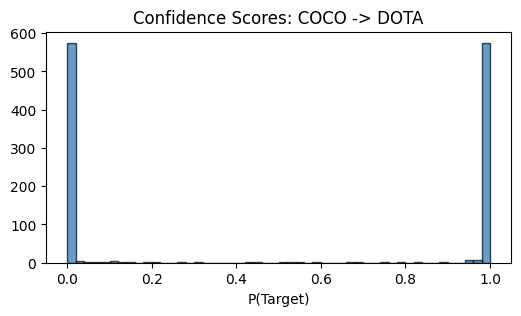

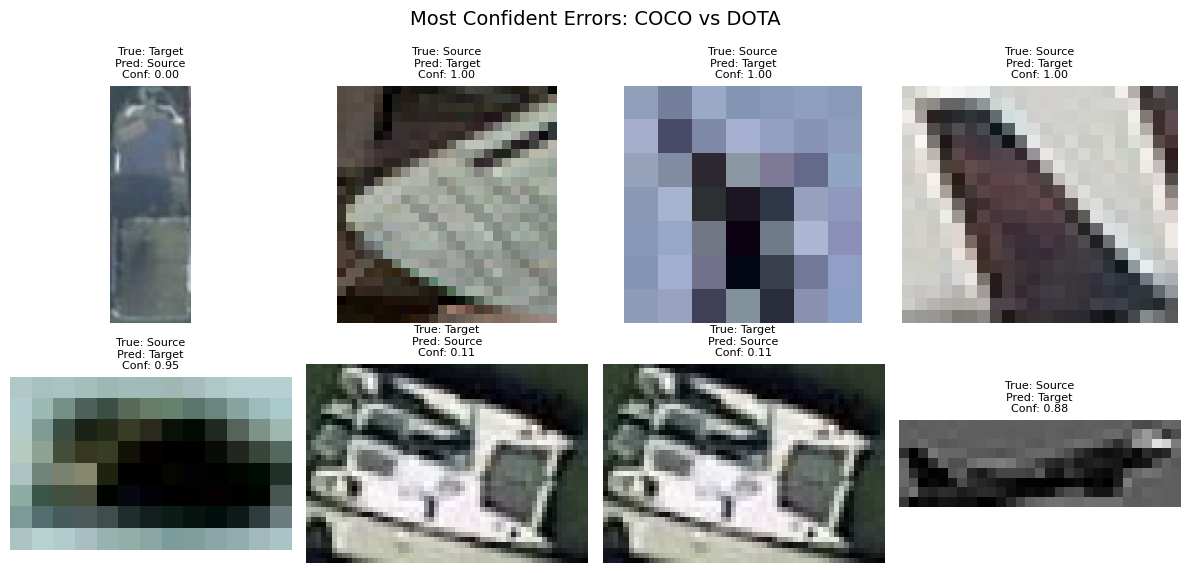


--- DIOR vs DOTA ---
Accuracy: 0.7750 | AUC: 0.8580


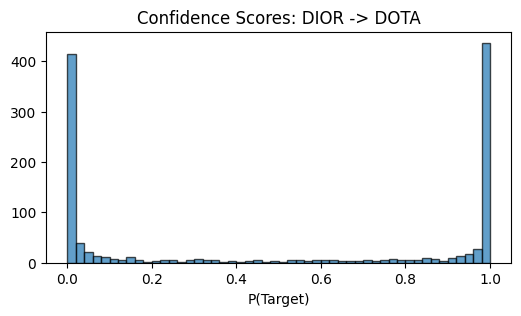

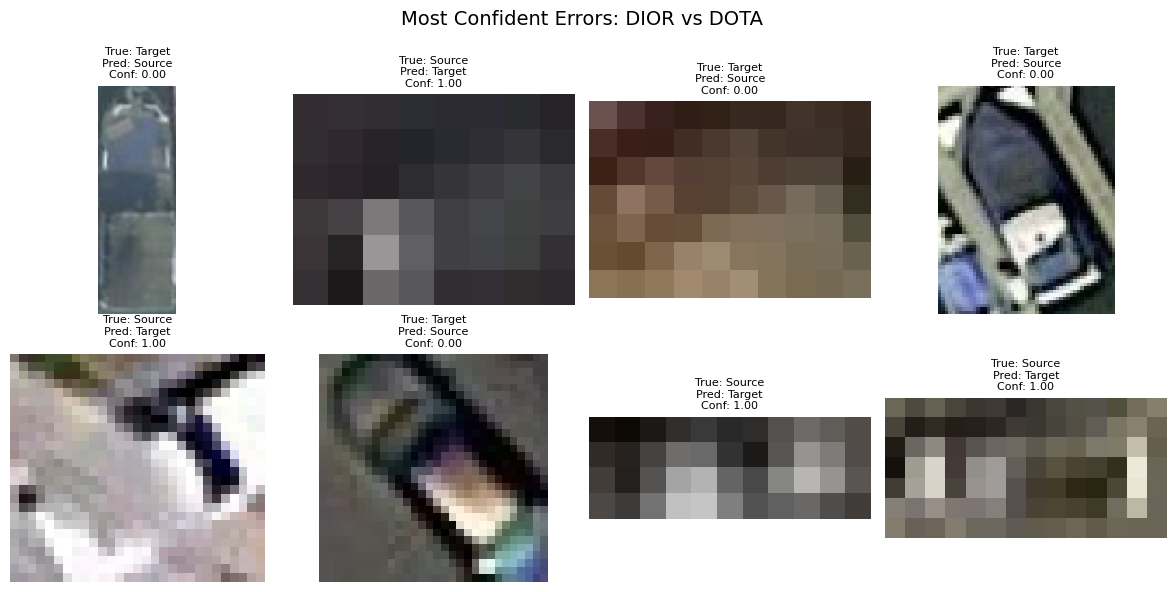

In [9]:
# ==========================================
# 4. DOMAIN CLASSIFIER (AUC, CONFIDENCE, IMAGES)
# ==========================================
def show_image_grid(items, title, n=12, cols=4):
    n = min(n, len(items))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        img, caption = items[i]
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(caption, fontsize=8)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def evaluate_pair(source_name, target_name, data):
    # Prepare Data
    X_src = data[source_name]["emb"]
    X_tgt = data[target_name]["emb"]
    y = np.hstack([np.zeros(len(X_src)), np.ones(len(X_tgt))])
    X = np.vstack([X_src, X_tgt])
    imgs = data[source_name]["imgs"] + data[target_name]["imgs"]

    # Split
    idx_train, idx_test, y_train, y_test = train_test_split(
        np.arange(len(y)), y, test_size=0.3, stratify=y, random_state=42
    )

    # Train Classifier
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000).fit(scaler.fit_transform(X[idx_train]), y_train)

    # Predict
    probs = clf.predict_proba(scaler.transform(X[idx_test]))[:, 1]
    y_pred = (probs >= 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, probs)
    print(f"\n--- {source_name} vs {target_name} ---")
    print(f"Accuracy: {acc:.4f} | AUC: {auc:.4f}")

    # Plot Confidence Histogram
    plt.figure(figsize=(6, 3))
    plt.hist(probs, bins=50, range=(0,1), edgecolor='black', alpha=0.7)
    plt.title(f"Confidence Scores: {source_name} -> {target_name}")
    plt.xlabel("P(Target)")
    plt.show()

    # Show Misclassified / Ambiguous Images
    # Find samples where prediction was WRONG
    wrong_mask = (y_pred != y_test)
    if np.any(wrong_mask):
        wrong_indices = idx_test[wrong_mask]
        wrong_probs = probs[wrong_mask]
        wrong_preds = y_pred[wrong_mask]

        # Sort by confidence (most confident errors first)
        conf_metric = np.abs(wrong_probs - 0.5)
        sort_idx = np.argsort(-conf_metric) # Descending

        display_items = []
        for i in sort_idx[:8]: # Show top 8
            idx_global = wrong_indices[i]
            p = wrong_probs[i]
            lbl = "Target" if y[idx_global]==1 else "Source"
            pred_lbl = "Target" if wrong_preds[i]==1 else "Source"
            display_items.append((imgs[idx_global], f"True: {lbl}\nPred: {pred_lbl}\nConf: {p:.2f}"))

        show_image_grid(display_items, f"Most Confident Errors: {source_name} vs {target_name}")

# Run Evaluation
evaluate_pair("COCO", "DOTA", data)
evaluate_pair("DIOR", "DOTA", data)


Running t-SNE...


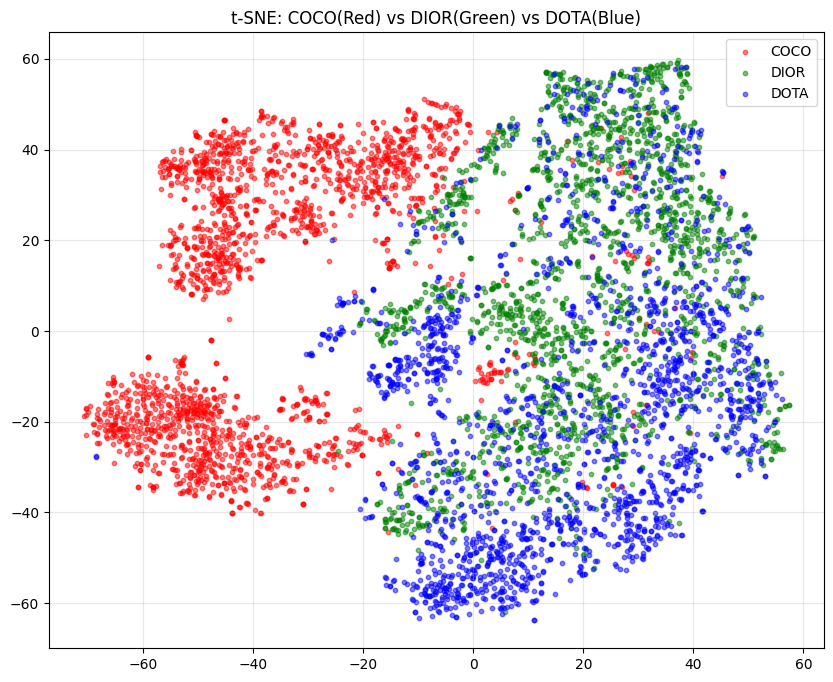

In [10]:
# ==========================================
# 5. VISUALIZATION (t-SNE & UMAP)
# ==========================================
# Prepare merged data for visualization
domains = ["COCO", "DIOR", "DOTA"]
X_all = np.vstack([data[d]["emb"] for d in domains])
domain_labels = np.concatenate([np.full(len(data[d]["emb"]), i) for i, d in enumerate(domains)])

# t-SNE
print("\nRunning t-SNE...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_all)

plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
for i, d in enumerate(domains):
    mask = (domain_labels == i)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.5, c=colors[i], label=d)
plt.title("t-SNE: COCO(Red) vs DIOR(Green) vs DOTA(Blue)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


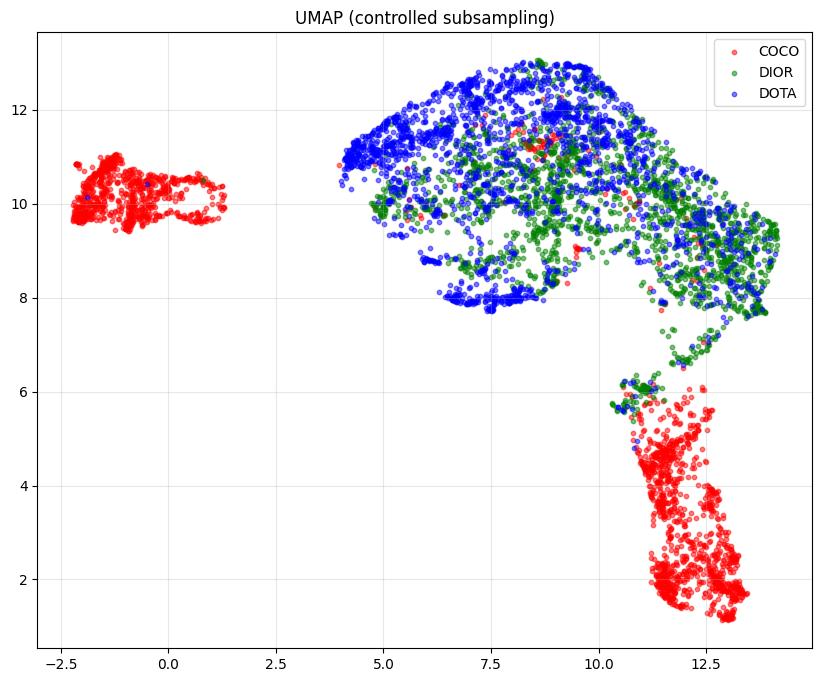

In [11]:
# UMAP
print("\nRunning UMAP...")
umapper = umap.UMAP(n_components=2, random_state=42)
X_umap = umapper.fit_transform(X_all)

plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
for i, d in enumerate(domains):
    mask = (domain_labels == i)
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], s=10, alpha=0.5, c=colors[i], label=d)
plt.title("UMAP (controlled subsampling)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()